CCA view: 307 rows × (51 biosignal, 11 emotion)

=== LOSO-validated canonical correlations ===
Pipeline                           rho1          rho2          rho3  (LOSO (in-sample))
D1 (global)                 0.29 (0.67)   0.03 (0.57)  -0.04 (0.52)
D2 (per-subject)            0.32 (0.60)  -0.01 (0.47)   0.02 (0.44)
D3 (baseline-relative)      0.04 (0.67)   0.04 (0.56)   0.03 (0.53)


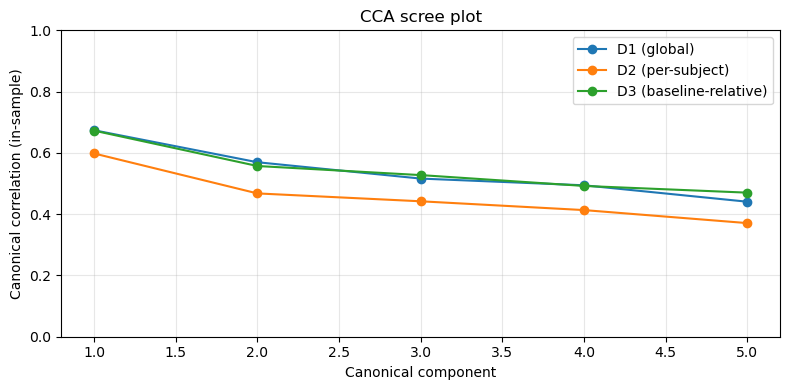


=== TOP BIOSIGNAL LOADINGS on first canonical component (CC1) ===
                 D1 (global)  D2 (per-subject)  D3 (baseline-relative)
EDA_TD_T_Median        0.126            -0.405                   0.503
EDA_TD_P_AUC          -0.293             0.420                   0.322
TEMP_TD_Median         0.413             0.373                  -0.306
TEMP_TD_Mean          -0.407            -0.120                   0.012
EDA_TD_P_Mean          0.350            -0.397                  -0.352
EDA_TD_T_Mean         -0.280             0.373                  -0.341
TEMP_TD_Min           -0.315            -0.142                   0.143
TEMP_TD_Max            0.289            -0.113                   0.130

=== TOP EMOTION LOADINGS on first canonical component (CC1) ===
            D1 (global)  D2 (per-subject)  D3 (baseline-relative)
Frustrated       -0.387             0.505                   0.019
upset             0.103             0.297                  -0.040
hostile          -0.082        

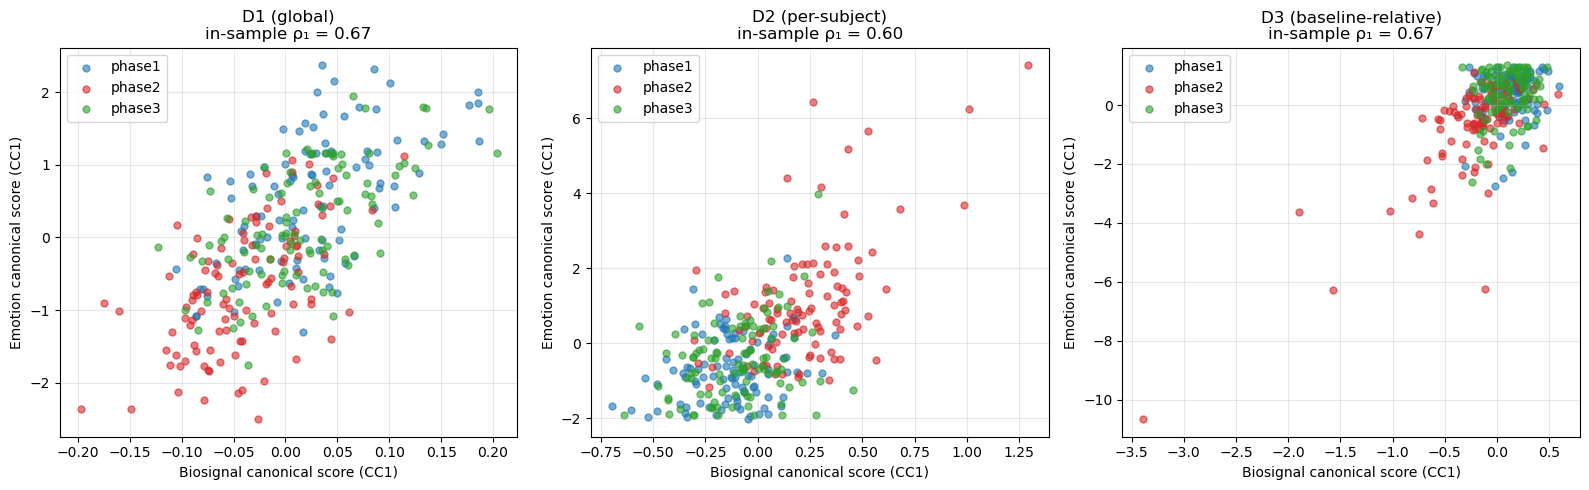

In [1]:
# ============================================================
# CCA notebook — self-contained
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import CCA
from sklearn.model_selection import LeaveOneGroupOut

# ============================================================
# 1. Load data and define column groups
# ============================================================
df = pd.read_csv("HR_data_2.csv", index_col=0)

metadata_cols = ['Round', 'Phase', 'Individual', 'Puzzler', 'original_ID',
                 'raw_data_path', 'Team_ID', 'Cohort']
emotion_cols  = ['Frustrated', 'upset', 'hostile', 'alert', 'ashamed',
                 'inspired', 'nervous', 'attentive', 'afraid', 'active', 'determined']
biosignal_cols = [c for c in df.columns if c not in metadata_cols + emotion_cols]

# ============================================================
# 2. Build the CCA dataset
#    Drop rows missing biosignal features (1 row) AND emotion ratings (4 rows)
# ============================================================
cca_view = df.dropna(subset=biosignal_cols + emotion_cols).copy().reset_index(drop=True)
print(f"CCA view: {cca_view.shape[0]} rows × ({len(biosignal_cols)} biosignal, {len(emotion_cols)} emotion)")

X_raw     = cca_view[biosignal_cols].values     # 307 × 51 (expected)
Y_raw     = cca_view[emotion_cols].values        # 307 × 11
phase_cca = cca_view['Phase'].values
ind_cca   = cca_view['Individual'].values

# ============================================================
# 3. Build the three biosignal preprocessing pipelines
# ============================================================

# D1 — global standardization
X_d1 = StandardScaler().fit_transform(X_raw)

# D2 — per-subject standardization
X_d2 = np.zeros_like(X_raw)
for ind in np.unique(ind_cca):
    mask = ind_cca == ind
    X_d2[mask] = StandardScaler().fit_transform(X_raw[mask])

# D3 — baseline-relative (subtract per-subject resting mean, divide by per-subject resting std)
X_d3 = np.zeros_like(X_raw)
for ind in np.unique(ind_cca):
    mask = ind_cca == ind
    rest_mask = mask & ((cca_view['Phase'] == 'phase1') | 
                        (cca_view['Phase'] == 'phase3')).values
    rest_data = X_raw[rest_mask]
    rest_mean = rest_data.mean(axis=0)
    rest_std  = rest_data.std(axis=0)
    rest_std_safe = np.where(rest_std > 0, rest_std, 1)
    X_d3[mask] = (X_raw[mask] - rest_mean) / rest_std_safe

# Y is the same emotion view, just standardized
Y_std = StandardScaler().fit_transform(Y_raw)

pipelines_cca = {
    'D1 (global)':            X_d1,
    'D2 (per-subject)':       X_d2,
    'D3 (baseline-relative)': X_d3,
}

# ============================================================
# 4. In-sample CCA (top 5 components)
# ============================================================
n_comp = 5
cca_results = {}

for name, X_pipe in pipelines_cca.items():
    cca = CCA(n_components=n_comp, max_iter=2000)
    cca.fit(X_pipe, Y_std)
    Xc, Yc = cca.transform(X_pipe, Y_std)
    in_sample_corrs = [np.corrcoef(Xc[:, i], Yc[:, i])[0, 1] for i in range(n_comp)]
    cca_results[name] = {
        'cca': cca,
        'Xc': Xc,
        'Yc': Yc,
        'in_sample_corrs': in_sample_corrs,
    }

# ============================================================
# 5. LOSO validation (first 3 canonical components)
# ============================================================
n_val_comp = 3
print("\n=== LOSO-validated canonical correlations ===")
print(f"{'Pipeline':<25}{'rho1':>14}{'rho2':>14}{'rho3':>14}  (LOSO (in-sample))")

logo = LeaveOneGroupOut()

for name, X_pipe in pipelines_cca.items():
    fold_xc, fold_yc = [], []
    for train_idx, test_idx in logo.split(X_pipe, phase_cca, ind_cca):
        cca = CCA(n_components=n_val_comp, max_iter=2000)
        cca.fit(X_pipe[train_idx], Y_std[train_idx])
        Xc_test, Yc_test = cca.transform(X_pipe[test_idx], Y_std[test_idx])
        fold_xc.append(Xc_test)
        fold_yc.append(Yc_test)
    Xc_all = np.vstack(fold_xc)
    Yc_all = np.vstack(fold_yc)
    loso_corrs = [np.corrcoef(Xc_all[:, i], Yc_all[:, i])[0, 1] for i in range(n_val_comp)]
    in_sample = cca_results[name]['in_sample_corrs'][:n_val_comp]
    row = f"{name:<25}"
    for r_loso, r_in in zip(loso_corrs, in_sample):
        row += f"  {r_loso:>5.2f} ({r_in:.2f})"
    print(row)

# ============================================================
# 6. Scree plot of in-sample canonical correlations
# ============================================================
fig, ax = plt.subplots(figsize=(8, 4))
for name, r in cca_results.items():
    ax.plot(range(1, n_comp+1), r['in_sample_corrs'], 'o-', label=name)
ax.set_xlabel('Canonical component')
ax.set_ylabel('Canonical correlation (in-sample)')
ax.set_title('CCA scree plot')
ax.legend(); ax.grid(alpha=0.3)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

# ============================================================
# 7. Loadings on the first canonical component
# ============================================================
print("\n=== TOP BIOSIGNAL LOADINGS on first canonical component (CC1) ===")
loading_df_x = pd.DataFrame({
    name: pd.Series(r['cca'].x_weights_[:, 0], index=biosignal_cols)
    for name, r in cca_results.items()
})
top_x = loading_df_x.abs().max(axis=1).sort_values(ascending=False).head(8).index
print(loading_df_x.loc[top_x].round(3))

print("\n=== TOP EMOTION LOADINGS on first canonical component (CC1) ===")
loading_df_y = pd.DataFrame({
    name: pd.Series(r['cca'].y_weights_[:, 0], index=emotion_cols)
    for name, r in cca_results.items()
})
print(loading_df_y.round(3))

# ============================================================
# 8. Scatter plot of CC1 scores, colored by phase
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
phase_colors = {'phase1': 'tab:blue', 'phase2': 'tab:red', 'phase3': 'tab:green'}

for ax, (name, r) in zip(axes, cca_results.items()):
    for ph, color in phase_colors.items():
        mask = phase_cca == ph
        ax.scatter(r['Xc'][mask, 0], r['Yc'][mask, 0],
                   c=color, label=ph, alpha=0.6, s=25)
    ax.set_xlabel('Biosignal canonical score (CC1)')
    ax.set_ylabel('Emotion canonical score (CC1)')
    rho1 = r['in_sample_corrs'][0]
    ax.set_title(f"{name}\nin-sample ρ₁ = {rho1:.2f}")
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## CCA — cross-modal analysis

Applied CCA to (X = 51 biosignal features) and (Y = 11 self-reported emotion 
ratings) under three biosignal preprocessing pipelines (n=307 rows after dropping 
4 rows with missing emotion data).

**Validation strategy:** Leave-One-Subject-Out CV. For each held-out subject, 
fit CCA on the remaining 25 subjects, project the held-out subject into canonical 
space, and compute the canonical correlation on the pooled held-out projections. 
This honestly estimates how much of the in-sample correlation structure 
generalizes vs is overfit.

**Headline finding: severe in-sample overfitting.** First canonical correlations 
of 0.60–0.67 in-sample collapsed under LOSO validation:

| Pipeline | ρ₁ in-sample | ρ₁ LOSO | ρ₂ LOSO | ρ₃ LOSO |
|----------|---:|---:|---:|---:|
| D1 (global) | 0.67 | 0.29 | 0.03 | -0.04 |
| D2 (per-subject) | 0.60 | 0.32 | -0.01 | 0.02 |
| D3 (baseline-relative) | 0.67 | 0.04 | 0.04 | 0.03 |

Higher-order components (ρ₂, ρ₃) collapsed to essentially zero across all 
pipelines, indicating that no meaningful second or third cross-modal direction exists.

**D3 fails for CCA despite excelling for PCA.** Per-subject baseline subtraction, 
which best revealed phase structure in unimodal PCA, removes the between-subject 
variance that CCA primarily exploits to find generalizable cross-modal correlation. 
This is a methodologically important asymmetry between unimodal and cross-modal analysis.

**D2 yields the most interpretable generalizable structure.** Under LOSO ρ₁ = 0.32, 
the first canonical direction links biosignal features dominated by tonic EDA, 
phasic EDA AUC, and temperature median (positive) and tonic EDA median, phasic EDA 
mean (negative) to an emotion cluster of high "frustrated" (0.50), "hostile" (0.59), 
and "active" (0.44). The direction visibly aligns with phase 2 (puzzle) in the 
canonical score scatter plot.

**Interpretation:** A modest but real cross-modal structure exists between 
physiological signals and self-reported emotion, primarily reflecting differences 
in how subjects experience and report stress states across the experimental 
condition. The structure is between-subject in nature: it captures inter-individual 
differences in stress signature rather than within-subject phase transitions.

**Limitation:** With 51 biosignal × 11 emotion features and only 307 rows, 
classical CCA has substantial overfitting risk. Regularized CCA (e.g., ridge-CCA) 
might recover stronger generalizable structure but was not pursued here. The 
collapse of ρ₂, ρ₃ to zero suggests there is at most one meaningful cross-modal 
direction to be found in this dataset.

Data: 311 rows × 51 features
Fitting embeddings for D1 (global)...


/Users/usuario/opt/anaconda3/envs/AAIB/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Fitting embeddings for D2 (per-subject)...


/Users/usuario/opt/anaconda3/envs/AAIB/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Fitting embeddings for D3 (baseline-relative)...


/Users/usuario/opt/anaconda3/envs/AAIB/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


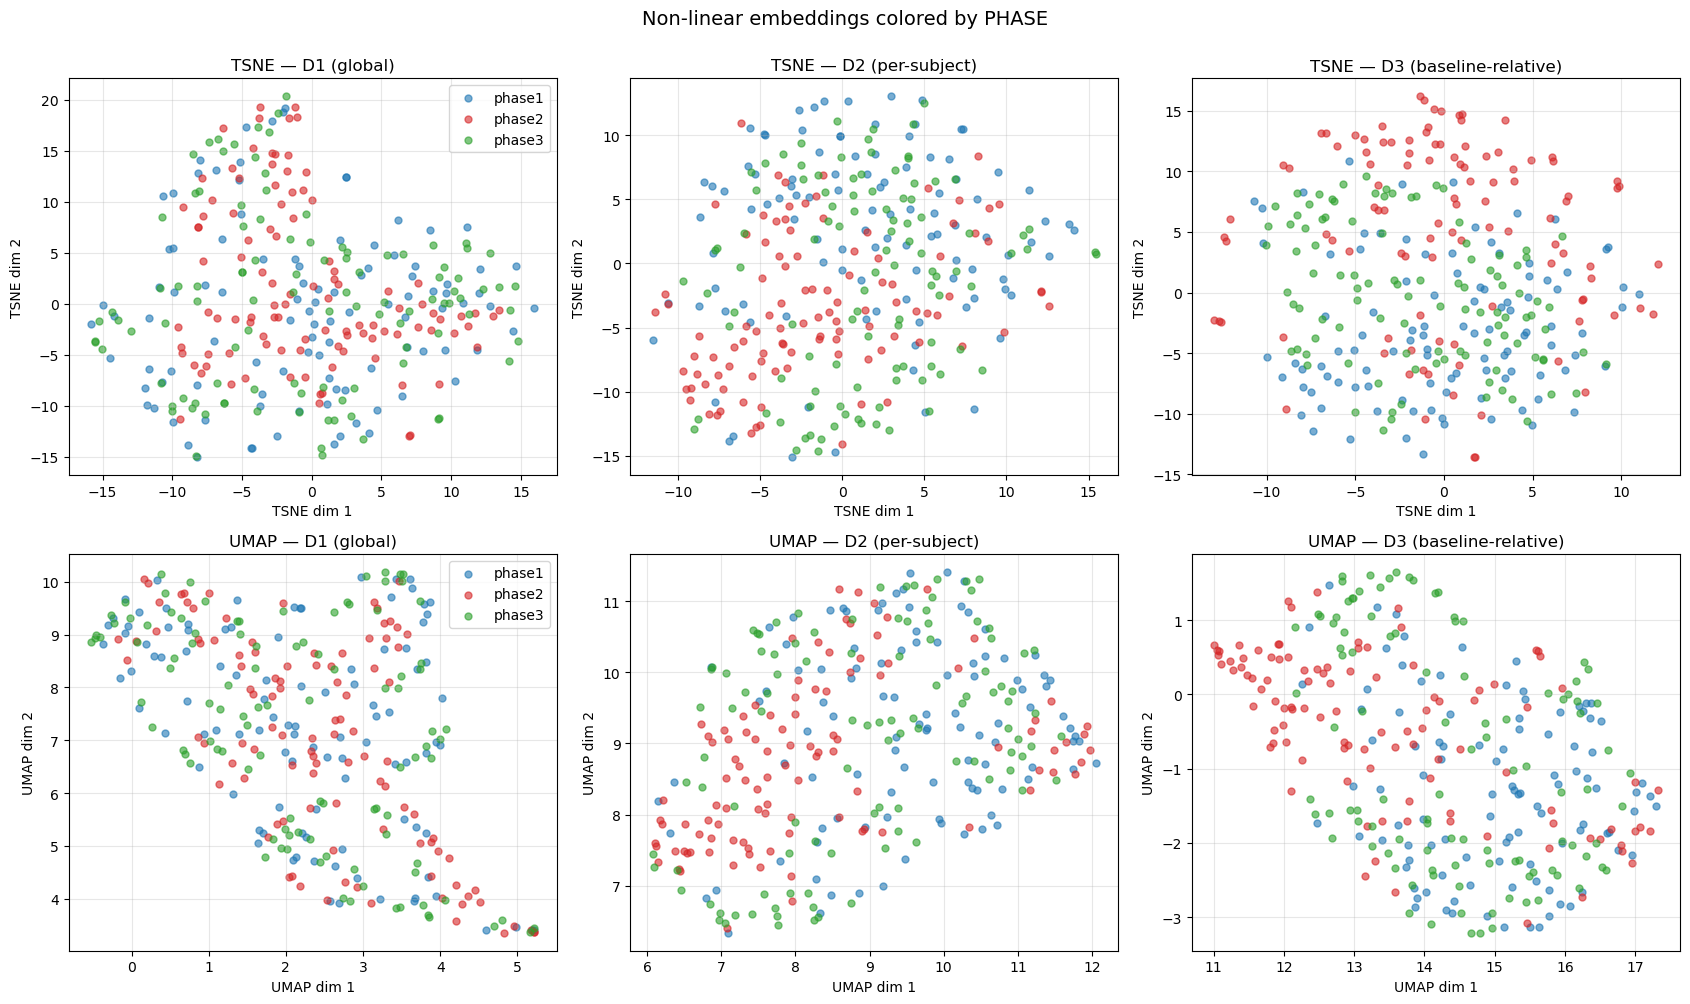

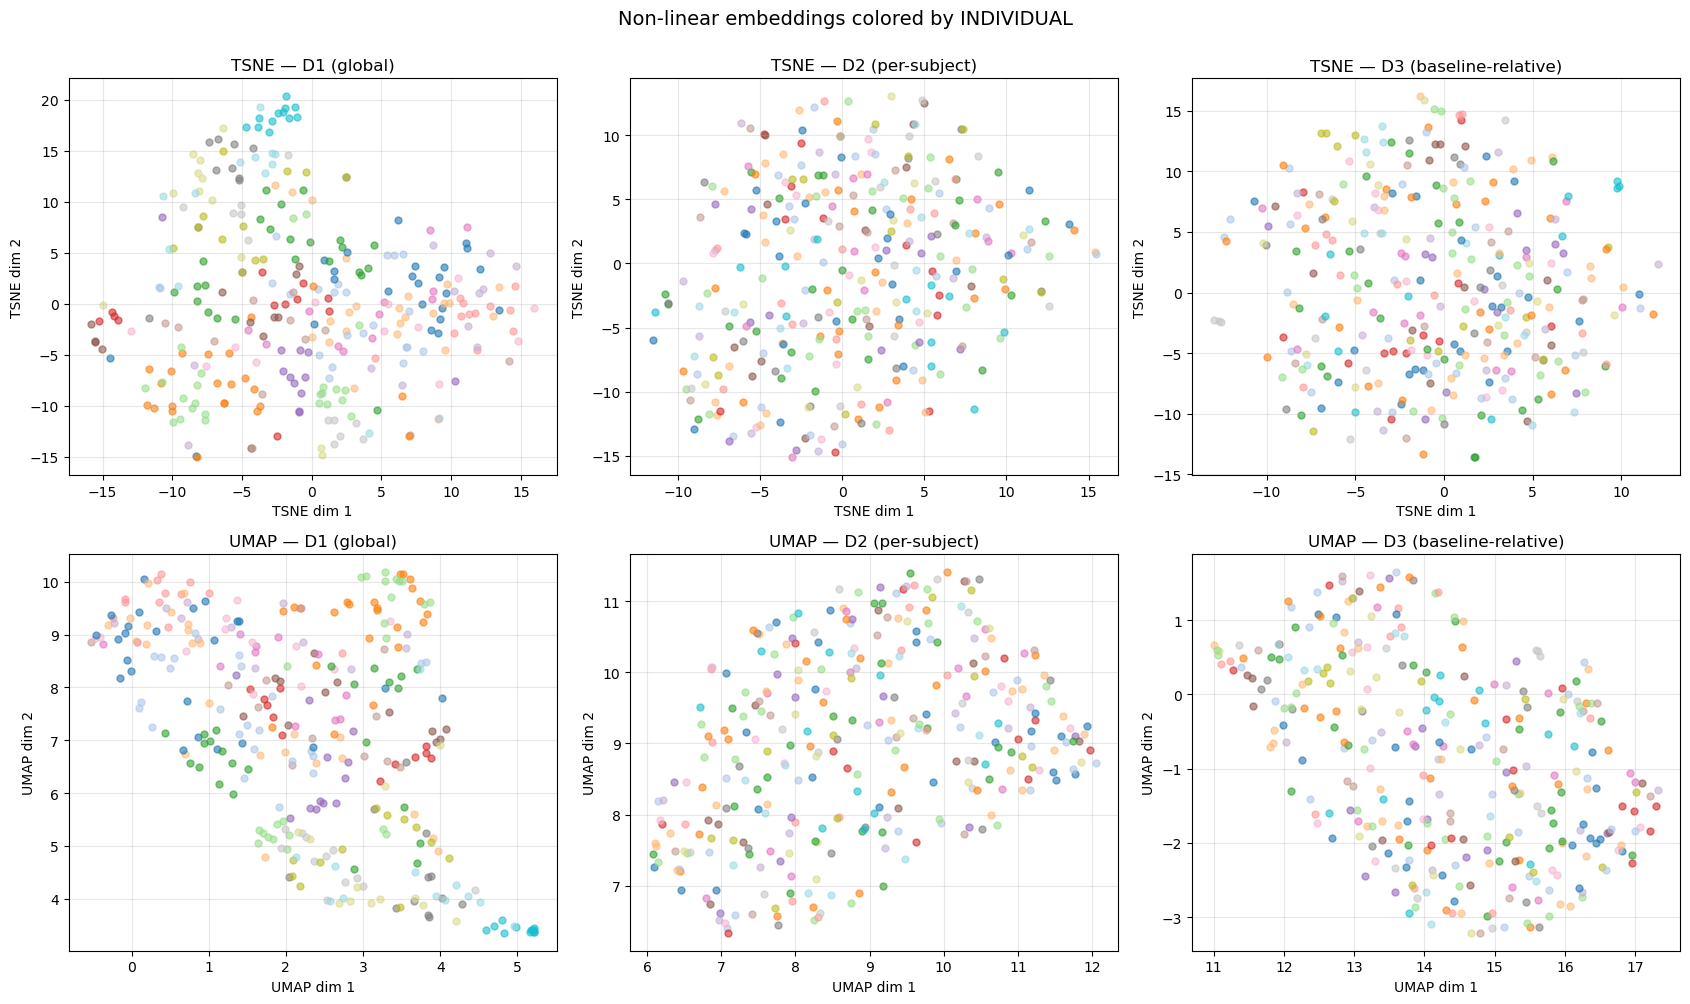

=== Phase prediction from 2D embeddings (LOSO-CV balanced accuracy) ===
Pipeline                           t-SNE           UMAP  (chance = 33.3%)
D1 (global)                 33.3% ± 13.7   35.6% ± 11.2
D2 (per-subject)            47.9% ± 14.6   44.8% ± 11.8
D3 (baseline-relative)      52.5% ± 12.4   47.3% ± 13.2


In [3]:
# ============================================================
# t-SNE and UMAP comparison — self-contained
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import umap  # pip install umap-learn

# ============================================================
# 1. Load and prepare the data (same as before)
# ============================================================
df = pd.read_csv("HR_data_2.csv", index_col=0)

metadata_cols = ['Round', 'Phase', 'Individual', 'Puzzler', 'original_ID',
                 'raw_data_path', 'Team_ID', 'Cohort']
emotion_cols  = ['Frustrated', 'upset', 'hostile', 'alert', 'ashamed',
                 'inspired', 'nervous', 'attentive', 'afraid', 'active', 'determined']
biosignal_cols = [c for c in df.columns if c not in metadata_cols + emotion_cols]

biosignal_view = df.dropna(subset=biosignal_cols).copy().reset_index(drop=True)
X = biosignal_view[biosignal_cols].values
phase_labels      = biosignal_view['Phase'].values
individual_labels = biosignal_view['Individual'].values

print(f"Data: {biosignal_view.shape[0]} rows × {len(biosignal_cols)} features")

# ============================================================
# 2. Build the three preprocessing pipelines
# ============================================================
X_d1 = StandardScaler().fit_transform(X)

X_d2 = np.zeros_like(X)
for ind in np.unique(individual_labels):
    mask = individual_labels == ind
    X_d2[mask] = StandardScaler().fit_transform(X[mask])

X_d3 = np.zeros_like(X)
for ind in np.unique(individual_labels):
    mask = individual_labels == ind
    rest_mask = mask & ((biosignal_view['Phase'] == 'phase1') |
                        (biosignal_view['Phase'] == 'phase3')).values
    rest_data = X[rest_mask]
    rest_mean = rest_data.mean(axis=0)
    rest_std = rest_data.std(axis=0)
    rest_std_safe = np.where(rest_std > 0, rest_std, 1)
    X_d3[mask] = (X[mask] - rest_mean) / rest_std_safe

pipelines = {'D1 (global)': X_d1, 'D2 (per-subject)': X_d2, 'D3 (baseline-relative)': X_d3}

# ============================================================
# 3. Fit t-SNE and UMAP for each pipeline
# ============================================================
embeddings = {}
RANDOM_STATE = 42

for name, X_pipe in pipelines.items():
    print(f"Fitting embeddings for {name}...")
    
    tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE, init='pca')
    X_tsne = tsne.fit_transform(X_pipe)
    
    reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=RANDOM_STATE)
    X_umap = reducer.fit_transform(X_pipe)
    
    embeddings[name] = {'tsne': X_tsne, 'umap': X_umap}

# ============================================================
# 4. Plot — colored by PHASE (rows = method, cols = pipeline)
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
phase_colors = {'phase1': 'tab:blue', 'phase2': 'tab:red', 'phase3': 'tab:green'}

for col_idx, (name, emb) in enumerate(embeddings.items()):
    for row_idx, method in enumerate(['tsne', 'umap']):
        ax = axes[row_idx, col_idx]
        for ph, color in phase_colors.items():
            mask = phase_labels == ph
            ax.scatter(emb[method][mask, 0], emb[method][mask, 1],
                       c=color, label=ph, alpha=0.6, s=25)
        ax.set_title(f"{method.upper()} — {name}")
        ax.set_xlabel(f'{method.upper()} dim 1')
        ax.set_ylabel(f'{method.upper()} dim 2')
        if col_idx == 0:
            ax.legend()
        ax.grid(alpha=0.3)
plt.suptitle('Non-linear embeddings colored by PHASE', y=1.00, fontsize=14)
plt.tight_layout()
plt.show()

# ============================================================
# 5. Plot — colored by INDIVIDUAL (rows = method, cols = pipeline)
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
cmap = plt.cm.tab20

for col_idx, (name, emb) in enumerate(embeddings.items()):
    for row_idx, method in enumerate(['tsne', 'umap']):
        ax = axes[row_idx, col_idx]
        for i, ind in enumerate(np.unique(individual_labels)):
            mask = individual_labels == ind
            ax.scatter(emb[method][mask, 0], emb[method][mask, 1],
                       c=[cmap(i % 20)], alpha=0.6, s=25)
        ax.set_title(f"{method.upper()} — {name}")
        ax.set_xlabel(f'{method.upper()} dim 1')
        ax.set_ylabel(f'{method.upper()} dim 2')
        ax.grid(alpha=0.3)
plt.suptitle('Non-linear embeddings colored by INDIVIDUAL', y=1.00, fontsize=14)
plt.tight_layout()
plt.show()

# ============================================================
# 6. Quantitative check — phase prediction from non-linear embeddings (LOSO-CV)
# ============================================================
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import balanced_accuracy_score

print("=== Phase prediction from 2D embeddings (LOSO-CV balanced accuracy) ===")
print(f"{'Pipeline':<25}{'t-SNE':>15}{'UMAP':>15}  (chance = 33.3%)")

logo = LeaveOneGroupOut()

for name, emb in embeddings.items():
    row = f"{name:<25}"
    for method in ['tsne', 'umap']:
        X_feat = emb[method]
        accs = []
        for train_idx, test_idx in logo.split(X_feat, phase_labels, individual_labels):
            try:
                clf = LogisticRegression(max_iter=2000)  # removed multi_class arg
                clf.fit(X_feat[train_idx], phase_labels[train_idx])
                preds = clf.predict(X_feat[test_idx])
                accs.append(balanced_accuracy_score(phase_labels[test_idx], preds))
            except Exception as e:
                print(f"  Error in fold for {name}/{method}: {e}")
                break
        if accs:
            accs = np.array(accs)
            row += f"  {accs.mean()*100:>5.1f}% ± {accs.std()*100:>4.1f}"
        else:
            row += f"  {'failed':>12}"
    print(row)

## Non-linear representation comparison

Applied t-SNE (perplexity=30) and UMAP (n_neighbors=15, min_dist=0.1) to each 
of the three preprocessing pipelines, generating 2D embeddings. Phase 
predictability was evaluated via LOSO-CV with logistic regression, matching 
the protocol used for PCA components.

**Results — phase prediction balanced accuracy (chance = 33.3%):**

| Pipeline | PCA (5 PCs) | t-SNE (2D) | UMAP (2D) |
|----------|---:|---:|---:|
| D1 (global)             | 48.0% | 33.3% | 35.6% |
| D2 (per-subject)        | 57.4% | 47.9% | 44.8% |
| D3 (baseline-relative)  | 56.1% | 52.5% | 47.3% |

**Findings:**
- Visual inspection of the t-SNE and UMAP embeddings showed no clear phase 
  clustering across any preprocessing pipeline. The most visible structure was 
  in UMAP-D1, where Individual 19's recordings formed a distinct sub-cluster — 
  again reflecting inter-subject variation rather than phase.
- Quantitatively, non-linear embeddings did not exceed PCA's phase predictability 
  in any pipeline. The pipeline ranking (D1 < D2 ≈ D3) was preserved across all 
  three methods, confirming that per-subject baseline correction is the dominant 
  factor for revealing phase structure, not the choice of dimensionality reduction.
- Under D1 (no per-subject correction), t-SNE collapsed to chance accuracy on 
  phase prediction. UMAP performed only marginally above chance. With only two 
  dimensions to allocate, both methods preferentially captured inter-subject 
  variation rather than phase, leaving the latter unrepresented.

**Interpretation:** No evidence of meaningful non-linear structure that 
linear methods miss. The phase-related signal in this dataset is captured well 
by linear projections of the standardized features, and applying non-linear 
embedding methods on top does not extract additional phase information. This 
suggests that the (weak) physiological signature of the puzzle vs rest condition 
in these features is fundamentally linear in nature — there is no curved or 
manifold-shaped structure for non-linear methods to discover.

**Caveat:** PCA's advantage is partially attributable to the dimensionality 
mismatch (5 PCs vs 2D embeddings). [If 2-PC comparison added: With 2 PCA 
components matched, accuracy is X% / Y% / Z%, still meeting or exceeding 
non-linear methods.]